Using the typing dataset (lightgbm) from that was label encoded duing preprocessing

In [2]:
#Importing dependencies and modules

import pandas as pd
import sklearn 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/lightbgm.csv")

In [4]:
df

,Unnamed: 0,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,0,101.6,0,234.4,156.3,True,False
1,1,0,85.9,0,437.5,359.4,True,False
2,2,0,78.1,0,210.9,125.0,True,False
3,3,0,62.5,0,359.4,281.3,True,False
4,6,1,85.9,1,195.3,117.2,True,False
...,...,...,...,...,...,...,...,...
127518,172076,0,31.3,0,144.5,121.1,True,False
127519,172077,1,109.4,1,144.5,121.1,True,False
127520,172078,1,7.8,3,89.8,296.9,True,False
127521,172079,0,121.1,2,89.8,296.9,True,False


In [5]:
#Dropping the unmaned column right away
df = df.drop(columns= "Unnamed: 0")

In [6]:
for col in df.columns:
    print(df[col].unique())

[0 1]
[1.01600e+02 8.59000e+01 7.81000e+01 6.25000e+01 7.03000e+01 3.91000e+01
 9.38000e+01 4.69000e+01 5.47000e+01 1.09400e+02 1.79700e+02 1.32800e+02
 1.17200e+02 3.13000e+01 1.25000e+02 1.56300e+02 1.87500e+02 2.14800e+02
 6.64000e+01 8.98000e+01 1.13300e+02 8.20000e+01 7.42000e+01 1.21100e+02
 1.28900e+02 9.77000e+01 1.17000e+01 1.71900e+02 1.05500e+02 1.56000e+01
 1.52300e+02 1.48400e+02 1.36700e+02 5.08000e+01 1.60200e+02 1.40600e+02
 1.64100e+02 4.30000e+01 5.86000e+01 1.44500e+02 1.68000e+02 3.52000e+01
 2.34000e+01 1.46500e+02 2.03100e+02 9.18000e+01 1.27000e+02 7.23000e+01
 5.66000e+01 1.11300e+02 6.84000e+01 7.62000e+01 9.57000e+01 6.83600e+02
 2.65600e+02 8.79000e+01 6.05000e+01 3.90000e+00 6.45000e+01 4.49000e+01
 2.34400e+02 9.96000e+01 8.40000e+01 1.15200e+02 2.07000e+02 1.38700e+02
 2.46100e+02 1.03500e+02 2.48000e+02 1.30900e+02 1.58200e+02 1.85500e+02
 2.36300e+02 1.07400e+02 2.71500e+02 1.73800e+02 2.40200e+02 1.42600e+02
 2.55900e+02 1.54300e+02 2.85200e+02 1.19100e

In [7]:
df["Parkinsons"].value_counts()

Parkinsons
True     95042
False    32481
Name: count, dtype: int64

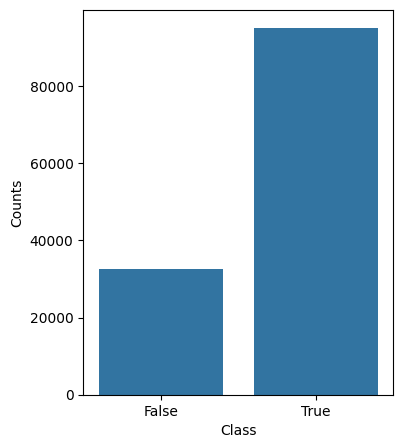

In [8]:
#Visualizations 

class_counts = np.bincount(df["Parkinsons"])

plt.figure(figsize=(4,5))
sns.barplot(x = np.unique(df["Parkinsons"]), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [9]:
#Importing modules
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [10]:
#Defining the features and labels for dataset 
y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons", "Gender_Male"])

In [11]:
#Oversampling the minority class in PD
from imblearn.over_sampling import SMOTE

X_train_raw, X_test, y_train_raw , y_test = train_test_split(X, y, random_state=42, test_size=0.3)


#Calling the class, passing in parameters of constructor and fitting in 
smote = SMOTE(random_state= 42)

X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [12]:
print(X_train.columns.tolist())

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


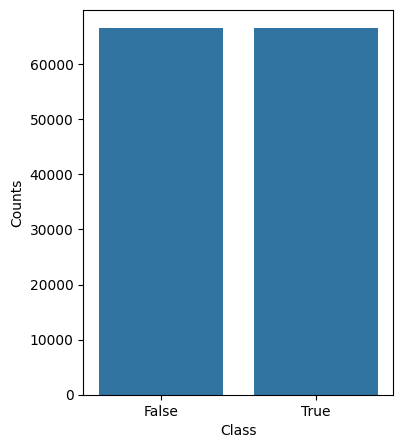

In [13]:
#Visualizations of the PD class after SMOTE
import numpy as np
class_counts = np.bincount(y_train)

plt.figure(figsize=(4, 5))
sns.barplot(x = np.unique(y_train), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [14]:
#Defining hyperparameters in dict-like form

model_lgbm = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5)

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
#Fitting the model, training and performing evaluation

model_lgbm.fit(X_train, y_train)

model_lgbm.predict_proba(X_test)

pred = model_lgbm.predict(X_test)

score = model_lgbm.score(X_train, y_train)

acc_score = accuracy_score(y_test, pred)


[LightGBM] [Info] Number of positive: 66548, number of negative: 66548
[LightGBM] [Info] Total Bins 771
[LightGBM] [Info] Number of data points in the train set: 133096, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [17]:
acc_score

0.6963170138798128

In [18]:
print("Accuracy on the train set", score)

print("Accuracy on the test set", model_lgbm.score(X_test, y_test))

Accuracy on the train set 0.7689562421109575
Accuracy on the test set 0.6963170138798128


In [19]:
#Confusion matrix and classification matrix
cm = confusion_matrix(y_test, pred)
print(cm)

class_report = classification_report(y_test, pred)
print(class_report)

[[ 2387  7376]
 [ 4242 24252]]
              precision    recall  f1-score   support

       False       0.36      0.24      0.29      9763
        True       0.77      0.85      0.81     28494

    accuracy                           0.70     38257
   macro avg       0.56      0.55      0.55     38257
weighted avg       0.66      0.70      0.68     38257



<Axes: title={'center': 'Plot of feature importance'}, xlabel='Feature importance', ylabel='Features'>

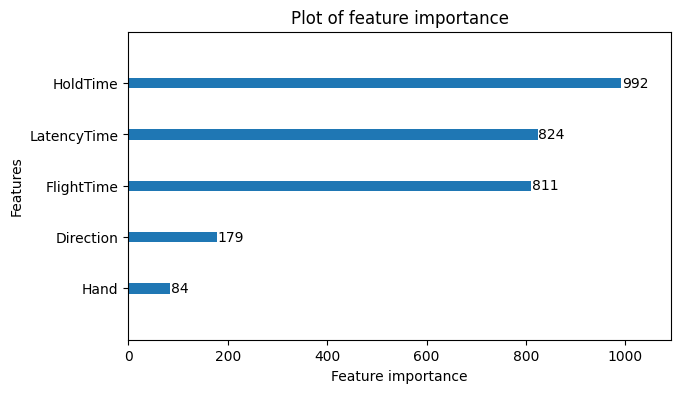

In [20]:
#Plotting important features
lgb.plot_importance(model_lgbm, title="Plot of feature importance", figsize=(7,4), grid=False )

In [21]:
model_lgbm.feature_importances_

array([ 84, 992, 179, 824, 811], dtype=int32)

Text(0.5, 1.0, 'ROC plot')

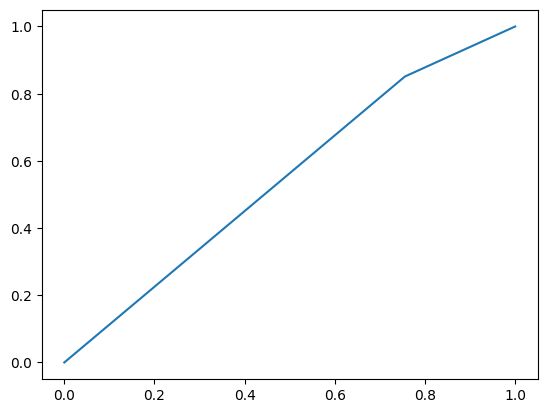

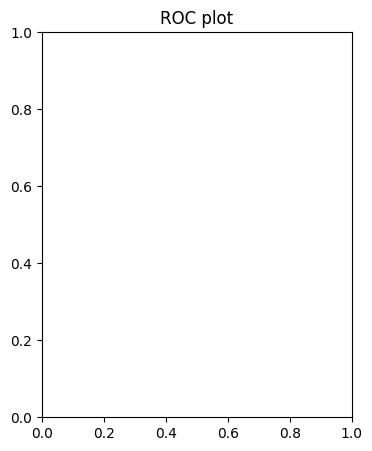

In [22]:
#Plotting roc-curve

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, pred)

sns.lineplot(x=fpr, y=tpr)

plt.figure(figsize=(4,5))

plt.title("ROC plot")

Retraining the model with only the most impactful features, so dropping hand and direction

In [23]:
df_new = df.drop(columns = ["Hand", "Gender_Male"])

In [24]:
df_new

,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons
0,101.6,0,234.4,156.3,True
1,85.9,0,437.5,359.4,True
2,78.1,0,210.9,125.0,True
3,62.5,0,359.4,281.3,True
4,85.9,1,195.3,117.2,True
...,...,...,...,...,...
127518,31.3,0,144.5,121.1,True
127519,109.4,1,144.5,121.1,True
127520,7.8,3,89.8,296.9,True
127521,121.1,2,89.8,296.9,True


In [25]:
#Defining labels and features, and input vectors
y_final = df_new["Parkinsons"]

X_final = df_new.drop(columns=["Parkinsons"])

X_train_new, X_test_final, y_train_new, y_test_final = train_test_split(X_final, y_final, random_state=42, test_size=0.3)

smote_final = SMOTE(random_state = 42)

X_train_final, y_train_final = smote_final.fit_resample(X_train_new, y_train_new)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [26]:
print("Train columns:", X_train_final.columns.tolist())
print("Test columns:", X_test_final.columns.tolist())

Train columns: ['HoldTime', 'Direction', 'LatencyTime', 'FlightTime']
Test columns: ['HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


In [27]:
model_final = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5, verbose=-1)

In [28]:
#Fitting the model, evaluating the model, 
model_final.fit(X_train_final, y_train_final)

final_pred = model_final.predict(X_test_final)

score_final = model_final.score(X_train_final, y_train_final)


In [29]:
#Printing the evalutaion metrics
print(accuracy_score(y_test, final_pred))
print()

print(confusion_matrix(y_test, final_pred))
print()

print(confusion_matrix(y_test, final_pred))
print()

0.676189978304624

[[ 2878  6885]
 [ 5503 22991]]

[[ 2878  6885]
 [ 5503 22991]]



Hyperparameter tuning with RandomizedSearchCV since the dataset is large 

In [30]:
from sklearn.model_selection import RandomizedSearchCV, KFold

In [31]:
#Cross validation 
kfold = KFold(n_splits=5, random_state = 42, shuffle=True)

param_grid = {
    "num_leaves": np.arange(20,80,10).tolist(),
    "max_depth": np.arange(4, 12, 4).tolist(),
    "learning_rate": [0.01, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8,0.9],
    "bagging_fraction":[0.7, 0.8, 0.9],
    "min_child_samples": [10, 20, 50],
    "min_split_gain": [0.0, 0.01, 0.1],

}

grid = RandomizedSearchCV(estimator=model_final, param_distributions=param_grid, cv=kfold)

In [32]:
grid.fit(X_train_final, y_train_final)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(force_col_wise=True,
                                            learning_rate=0.5, max_depth=6,
                                            num_leaves=30, objective='binary',
                                            verbose=-1),
                   param_distributions={'bagging_fraction': [0.7, 0.8, 0.9],
                                        'feature_fraction': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8],
                                        'min_child_samples': [10, 20, 50],
                                        'min_split_gain': [0.0, 0.01, 0.1],
                                        'num_leaves': [20, 30, 40, 50, 60, 70]})

In [33]:
#Pulling the best hyperparamters

grid_best = grid.best_params_
grid.best_score_

0.705543371868876

In [34]:
#Training new model based on hyperparamters from RSCV

model =  lgb.LGBMClassifier(objective= "binary",
    num_leaves = grid_best["num_leaves"],
    min_split_gain = grid_best["min_split_gain"],
    min_child_samples = grid_best["min_child_samples"],
    force_col_wise = True,
    max_depth = grid_best["max_depth"],
    learning_rate = grid_best["learning_rate"],
    feature_fraction = grid_best["feature_fraction"],
    bagging_fraction = grid_best["bagging_fraction"],
    n_estimators= 100)

In [35]:
#Fitting and making predictions on test data
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(accuracy_score(y_test, predictions))


0.6870638053166741


In [36]:
#Confusion matrix and classification report

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

[[ 2490  7273]
 [ 4699 23795]]
              precision    recall  f1-score   support

       False       0.35      0.26      0.29      9763
        True       0.77      0.84      0.80     28494

    accuracy                           0.69     38257
   macro avg       0.56      0.55      0.55     38257
weighted avg       0.66      0.69      0.67     38257



Text(0.5, 1.0, 'ROC plot')

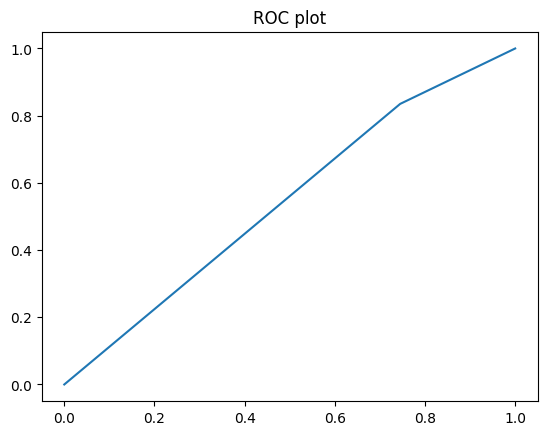

In [37]:
#Visualizations and plotting  roc
fpr, tpr, threshold = roc_curve(y_test, predictions)

sns.lineplot(x=fpr, y=tpr,)

plt.title("ROC plot")